In [219]:
#Imports 
import rasterio
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import f1_score, accuracy_score
from lightgbm import LGBMClassifier,early_stopping, log_evaluation
import numpy as np
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.ensemble import RandomForestClassifier

## Importing data:

In [220]:
back = rasterio.open("/kaggle/input/competitions/geohab-mlwg-competition-2026/MBES/backscatter.tif")
bath = rasterio.open("/kaggle/input/competitions/geohab-mlwg-competition-2026/MBES/bathymetry.tif")
train_df = pd.read_csv('/kaggle/input/competitions/geohab-mlwg-competition-2026/train.csv')
test_df = pd.read_csv('/kaggle/input/competitions/geohab-mlwg-competition-2026/test.csv')

In [221]:
print('Train set: ', train_df.shape)
display(train_df.head())

print('Test set: ', test_df.shape)
display(test_df.head())

back_data = back.read(1)
print('Backscatter data: ',back_data.shape)
print(back_data[:5, :5])

bath_data = bath.read(1)
print('Bathymestry data: ', bath_data.shape)
print(bath_data[:5, :5])

Train set:  (6256, 3)


,class,x,y
0,NVB,453594.477237,5.679192e+06
1,FMAT,453561.906453,5.679109e+06
2,ALG,453744.452238,5.679033e+06
3,ALG,453863.445302,5.679038e+06
4,ALG,453964.611906,5.679017e+06


Test set:  (98, 3)


,ID,x,y
0,1,453702.166779,5.679044e+06
1,2,454126.252800,5.678999e+06
2,3,453957.881092,5.678942e+06
3,4,453798.917484,5.678955e+06
4,5,453520.953671,5.679124e+06


Backscatter data:  (4040, 4743)
[[-10000. -10000. -10000. -10000. -10000.]
 [-10000. -10000. -10000. -10000. -10000.]
 [-10000. -10000. -10000. -10000. -10000.]
 [-10000. -10000. -10000. -10000. -10000.]
 [-10000. -10000. -10000. -10000. -10000.]]
Bathymestry data:  (4040, 4743)
[[-10000. -10000. -10000. -10000. -10000.]
 [-10000. -10000. -10000. -10000. -10000.]
 [-10000. -10000. -10000. -10000. -10000.]
 [-10000. -10000. -10000. -10000. -10000.]
 [-10000. -10000. -10000. -10000. -10000.]]


## Extracting Features:

### Grid feature

In [222]:
def get_neighborhood_features(x, y):
    row, col = bath.index(x, y)
    
    features = []
    
    for dr in [-12, 0, 12]:
        for dc in [-12, 0, 12]:
            r = row + dr
            c = col + dc
            
            try:
                depth = bath_data[r, c]
                scatter = back_data[r, c]
            except:
                depth = 0
                scatter = 0
            
            features.append(depth)
            features.append(scatter)
    
    return features

In [223]:
features = train_df.apply(
    lambda r: get_neighborhood_features(r['x'], r['y']),
    axis=1
)

train_feature_cols = [f'f{i}' for i in range(len(features.iloc[0]))]

train_df[train_feature_cols] = pd.DataFrame(features.tolist(), index=train_df.index)

In [224]:
print(train_feature_cols)

['f0', 'f1', 'f2', 'f3', 'f4', 'f5', 'f6', 'f7', 'f8', 'f9', 'f10', 'f11', 'f12', 'f13', 'f14', 'f15', 'f16', 'f17']


In [225]:
train_df.head()

,class,x,y,f0,f1,f2,f3,f4,f5,f6,...,f8,f9,f10,f11,f12,f13,f14,f15,f16,f17
0,NVB,453594.477237,5.679192e+06,-10000.000000,-10000.000000,-10000.000000,-10000.000000,-10000.000000,-10000.000000,-2.667833,...,-2.822883,-18.669088,-3.003832,-16.779381,-3.052902,-17.719353,-3.153770,-18.979156,-3.217835,-21.499985
1,FMAT,453561.906453,5.679109e+06,-5.861867,-24.649494,-5.705794,-19.609058,-5.636959,-19.928892,-5.808707,...,-5.668992,-20.558794,-5.697957,-22.129887,-6.120852,-20.558794,-5.797802,-21.189917,-6.232965,-21.189917
2,ALG,453744.452238,5.679033e+06,-9.233783,-24.339426,-8.520893,-24.019592,-8.426841,-24.339426,-9.579664,...,-9.288988,-23.389690,-9.054879,-23.709524,-9.672694,-27.169104,-10.006989,-21.189917,-10.029820,-23.709524
3,ALG,453863.445302,5.679038e+06,-6.856915,-24.339426,-6.731852,-24.339426,-6.698797,-25.599232,-7.546973,...,-7.263793,-21.189917,-6.937677,-22.449720,-8.047904,-19.609058,-7.883994,-18.039186,-7.642729,-21.819818
4,ALG,453964.611906,5.679017e+06,-8.769996,-24.339426,-7.727922,-20.238960,-7.976172,-24.649494,-9.685985,...,-9.784807,-22.449720,-8.631302,-28.749962,-10.117740,-25.599232,-10.628894,-27.169104,-10.871862,-27.488937


### Advanced feature engineering:

In [226]:
def get_advanced_features(x, y):
    row, col = bath.index(x, y)
    
    depths = []
    scatters = []
    
    for dr in [-10, 0, 10]:
        for dc in [-10, 0, 10]:
            r = row + dr
            c = col + dc
            
            if 0 <= r < bath_data.shape[0] and 0 <= c < bath_data.shape[1]:
                depths.append(bath_data[r, c])
                scatters.append(back_data[r, c])
            else:
                depths.append(0)
                scatters.append(0)
    
    return [
        np.mean(depths),
        np.std(depths),
        np.min(depths),
        np.max(depths),
        np.mean(scatters),
        np.std(scatters),
        np.min(scatters),
        np.max(scatters),
    ]

In [227]:
features = train_df.apply(
    lambda r: get_advanced_features(r['x'], r['y']),
    axis=1
)

adv_feature_cols = [
    'depth_mean', 'depth_std', 'depth_min', 'depth_max',
    'scatter_mean', 'scatter_std', 'scatter_min', 'scatter_max'
]

train_df[adv_feature_cols] = pd.DataFrame(features.tolist(), index=train_df.index)

In [228]:
print(adv_feature_cols)

['depth_mean', 'depth_std', 'depth_min', 'depth_max', 'scatter_mean', 'scatter_std', 'scatter_min', 'scatter_max']


## Model:

In [229]:
target = 'class'

X = train_df[train_feature_cols + adv_feature_cols]
y = train_df[target].map({'SGAM': 0, 'NVB': 1, 'SGZ': 2, 'ALG': 3, 'FMAT': 4})

#splitting the data into train/val splits
X_train , X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=24)

### LGBM

In [230]:
model = LGBMClassifier(random_state=42, class_weight='balanced')
model.fit(X_train,y_train)

LGBMClassifier(class_weight='balanced', random_state=42)

In [231]:
val_preds = model.predict(X_val)
val_acc = accuracy_score(y_val, val_preds)
val_f1 = f1_score(y_val, val_preds, average='weighted')

print('Validation accuracy LGBM: ', val_acc)
print('Validation f1 LGBM: ', val_f1)

Validation accuracy LGBM:  0.944888178913738
Validation f1 LGBM:  0.9450109737527852


#### Feature Importance LGBM

In [232]:
import lightgbm as lgbm
import matplotlib.pyplot as plt

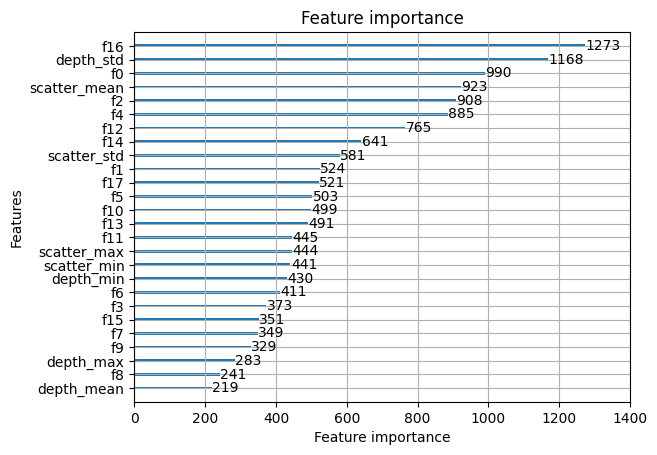

In [233]:
lgbm.plot_importance(model, max_num_features=30)
plt.show()

In [234]:
features = train_feature_cols + adv_feature_cols
importance = pd.Series(model.feature_importances_, index=features)
importance = importance.sort_values()

print(importance)

depth_mean       219
f8               241
depth_max        283
f9               329
f7               349
f15              351
f3               373
f6               411
depth_min        430
scatter_min      441
scatter_max      444
f11              445
f13              491
f10              499
f5               503
f17              521
f1               524
scatter_std      581
f14              641
f12              765
f4               885
f2               908
scatter_mean     923
f0               990
depth_std       1168
f16             1273
dtype: int32


### XGBoost

In [235]:
model = XGBClassifier(random_state=42)
model.fit(X_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [236]:
val_preds = model.predict(X_val)
val_acc = accuracy_score(y_val, val_preds)
val_f1 = f1_score(y_val, val_preds, average='weighted')

print('Validation accuracy XGB: ', val_acc)
print('Validation f1 XGB: ', val_f1)

Validation accuracy XGB:  0.939297124600639
Validation f1 XGB:  0.9391736176672016


In [237]:
features = train_feature_cols + adv_feature_cols
importance = pd.Series(model.feature_importances_, index=features)
importance = importance.sort_values()

print(importance)

f3              0.008712
f9              0.010068
f15             0.013097
f1              0.014842
f7              0.016992
f17             0.017373
scatter_std     0.017532
f5              0.017705
f13             0.017827
f6              0.020362
f8              0.020390
f14             0.022729
f11             0.026248
f0              0.032484
f12             0.033781
f4              0.035978
depth_max       0.038893
f16             0.043197
scatter_min     0.044083
f10             0.046196
scatter_max     0.058151
f2              0.060311
scatter_mean    0.072015
depth_min       0.073998
depth_mean      0.094633
depth_std       0.142402
dtype: float32


### RandomForest

In [238]:
rf_params = {'n_estimators': 974, 
	'max_depth': 25, 
	'min_samples_split': 3, 
	'min_samples_leaf': 1, 
	'max_features': 'log2', 
	'bootstrap': False, 
	'class_weight': 'balanced',
    'n_jobs':-1
}

In [239]:
model = RandomForestClassifier(random_state=42,
                              **rf_params)
model.fit(X_train,y_train)

RandomForestClassifier(bootstrap=False, class_weight='balanced', max_depth=25,
                       max_features='log2', min_samples_split=3,
                       n_estimators=974, n_jobs=-1, random_state=42)

In [240]:
val_preds = model.predict(X_val)
val_acc = accuracy_score(y_val, val_preds)
val_f1 = f1_score(y_val, val_preds, average='weighted')

print('Validation accuracy RF: ', val_acc)
print('Validation f1 RF: ', val_f1)

Validation accuracy RF:  0.9544728434504792
Validation f1 RF:  0.9543110381597666


In [241]:
features = train_feature_cols + adv_feature_cols
importance = pd.Series(model.feature_importances_, index=features)
importance = importance.sort_values()

print(importance)

f15             0.012322
f9              0.012486
f3              0.012822
f7              0.014320
f11             0.014494
f13             0.016154
f17             0.016385
f1              0.016425
f5              0.020408
scatter_min     0.033121
f8              0.033499
f6              0.036155
scatter_std     0.036905
f0              0.038643
depth_mean      0.039691
depth_max       0.042840
scatter_max     0.045973
f10             0.046847
f2              0.047897
f12             0.050716
f14             0.053940
f4              0.053981
depth_min       0.063438
f16             0.064439
scatter_mean    0.064790
depth_std       0.111311
dtype: float64


## OOF preds

In [242]:
features = test_df.apply(
    lambda r: get_neighborhood_features(r['x'], r['y']),
    axis=1
)

test_feature_cols = [f'f{i}' for i in range(len(features.iloc[0]))]

test_df[test_feature_cols] = pd.DataFrame(features.tolist(), index=test_df.index)

In [243]:
features = test_df.apply(
    lambda r: get_advanced_features(r['x'], r['y']),
    axis=1
)

test_df[adv_feature_cols] = pd.DataFrame(features.tolist(), index=test_df.index)

In [244]:
X_test = test_df[test_feature_cols + adv_feature_cols]

## Seed averaging

In [245]:
seeds = [42, 52, 62, 72, 82]

In [247]:
N_CLASSES = len(np.unique(y))

# ── LightGBM hyperparameters (Optuna-tuned) ───────────────────────────────────
lgb_params = {
    'n_estimators': 1879,
 	'learning_rate': 0.0765079139135192,
 	'num_leaves': 57,
 	'max_depth': 13,
 	'min_child_samples': 23,
 	'subsample': 0.9491400225657889,
 	'colsample_bytree': 0.6671968380388436,
	'reg_alpha': 0.002067039466798589,
 	'reg_lambda': 0.004458960681919556,
    "class_weight": "balanced",
    "device": "gpu",
    "n_jobs": -1,
    "verbose": -1,
}

# ── RF hyperparameters ───────────────────────────────────────────────────
rf_params = {'n_estimators': 974, 
	'max_depth': 25, 
	'min_samples_split': 3, 
	'min_samples_leaf': 1, 
	'max_features': 'log2', 
	'bootstrap': False, 
	'class_weight': 'balanced',
    'n_jobs': -1
}


# ── Blending weight: 50/50 LGB + RF ─────────────────────────────────────────
# Equal weight is a safe starting point. You can tune this if you add OOF scoring.
LGB_WEIGHT = 0.5
RF_WEIGHT = 0.5

seeds = [42, 52, 62, 72, 82]

final_test_probs_lgb = np.zeros((len(X_test), N_CLASSES))
final_test_probs_rf = np.zeros((len(X_test), N_CLASSES))

# OOF arrays to track performance across seeds
oof_lgb_all = np.zeros(len(X))
oof_rf_all = np.zeros(len(X))

for seed in seeds:
    print(f"\n{'='*50}")
    print(f"Seed {seed}")
    print(f"{'='*50}")

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    lgb_params["random_state"] = seed
    rf_params["random_state"] = seed

    test_probs_lgb = np.zeros((len(X_test), N_CLASSES))
    test_probs_rf = np.zeros((len(X_test), N_CLASSES))

    oof_lgb = np.zeros((len(X), N_CLASSES))
    oof_rf = np.zeros((len(X), N_CLASSES))

    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
        X_tr, y_tr = X.iloc[train_idx], y.iloc[train_idx]
        X_va, y_va = X.iloc[val_idx], y.iloc[val_idx]

        # ── LightGBM ──────────────────────────────────────────────────────────
        lgb_model = LGBMClassifier(**lgb_params)
        lgb_model.fit(
            X_tr, y_tr,
            eval_set=[(X_va, y_va)],
            # callbacks=[early_stopping(50, verbose=False), log_evaluation(0)]
        )
        oof_lgb[val_idx] = lgb_model.predict_proba(X_va)
        test_probs_lgb  += lgb_model.predict_proba(X_test) / skf.n_splits

        lgb_fold_f1 = f1_score(y_va, np.argmax(oof_lgb[val_idx], axis=1), average='weighted')

        # ── XGBoost ───────────────────────────────────────────────────────────
        rf_model = RandomForestClassifier(**rf_params)
        rf_model.fit(X_tr, y_tr)
        
        oof_rf[val_idx] = rf_model.predict_proba(X_va)
        test_probs_rf  += rf_model.predict_proba(X_test) / skf.n_splits

        rf_fold_f1 = f1_score(y_va, np.argmax(oof_rf[val_idx], axis=1), average='weighted')

        print(f"  Fold {fold+1}/5  |  LGB F1: {lgb_fold_f1:.4f}  |  RF F1: {rf_fold_f1:.4f}")

    # OOF score for this seed
    seed_lgb_oof_f1 = f1_score(y, np.argmax(oof_lgb, axis=1), average='weighted')
    seed_rf_oof_f1 = f1_score(y, np.argmax(oof_rf, axis=1), average='weighted')
    blend_oof = LGB_WEIGHT * oof_lgb + RF_WEIGHT * oof_xgb
    seed_blend_f1 = f1_score(y, np.argmax(blend_oof, axis=1), average='weighted')

    print(f"  Seed {seed} OOF  |  LGB: {seed_lgb_oof_f1:.4f}  |  RF: {seed_rf_oof_f1:.4f}  |  Blend: {seed_blend_f1:.4f}")

    final_test_probs_lgb += test_probs_lgb / len(seeds)
    final_test_probs_rf += test_probs_rf / len(seeds)

# ── Final blend ───────────────────────────────────────────────────────────────
final_test_probs = LGB_WEIGHT * final_test_probs_lgb + RF_WEIGHT * final_test_probs_rf

print(f"\nDone! Final predictions blended: {LGB_WEIGHT:.0%} LGB + {RF_WEIGHT:.0%} RF")


Seed 42
  Fold 1/5  |  LGB F1: 0.9552  |  RF F1: 0.9502
  Fold 2/5  |  LGB F1: 0.9624  |  RF F1: 0.9640
  Fold 3/5  |  LGB F1: 0.9473  |  RF F1: 0.9416
  Fold 4/5  |  LGB F1: 0.9567  |  RF F1: 0.9573
  Fold 5/5  |  LGB F1: 0.9599  |  RF F1: 0.9527
  Seed 42 OOF  |  LGB: 0.9563  |  RF: 0.9532  |  Blend: 0.9541

Seed 52
  Fold 1/5  |  LGB F1: 0.9561  |  RF F1: 0.9494
  Fold 2/5  |  LGB F1: 0.9632  |  RF F1: 0.9656
  Fold 3/5  |  LGB F1: 0.9481  |  RF F1: 0.9409
  Fold 4/5  |  LGB F1: 0.9591  |  RF F1: 0.9565
  Fold 5/5  |  LGB F1: 0.9624  |  RF F1: 0.9511
  Seed 52 OOF  |  LGB: 0.9578  |  RF: 0.9527  |  Blend: 0.9554

Seed 62
  Fold 1/5  |  LGB F1: 0.9560  |  RF F1: 0.9478
  Fold 2/5  |  LGB F1: 0.9632  |  RF F1: 0.9624
  Fold 3/5  |  LGB F1: 0.9513  |  RF F1: 0.9424
  Fold 4/5  |  LGB F1: 0.9568  |  RF F1: 0.9565
  Fold 5/5  |  LGB F1: 0.9567  |  RF F1: 0.9527
  Seed 62 OOF  |  LGB: 0.9568  |  RF: 0.9524  |  Blend: 0.9541

Seed 72
  Fold 1/5  |  LGB F1: 0.9536  |  RF F1: 0.9518
  Fold 

In [248]:
classes = np.array(['SGAM', 'NVB', 'SGZ', 'ALG', 'FMAT'])

final_preds = classes[np.argmax(final_test_probs, axis=1)]

submission = pd.DataFrame({
    'ID': test_df['ID'],
    target: final_preds
})

submission.to_csv('submission_seed_avg_lgb_rf.csv', index=False)
print('Submission saved: submission_seed_avg_lgb_rf.csv')
print(f'Prediction distribution:\n{pd.Series(final_preds).value_counts()}')

Submission saved: submission_seed_avg_lgb_rf.csv
Prediction distribution:
NVB     43
ALG     20
FMAT    19
SGAM     9
SGZ      7
Name: count, dtype: int64
